#**Objetivos**
* Construir Pipelines de procesamiento de datos.
* Probar modelos de Regresión logística y modelos de árboles.
* Probar técnicas de balanceo y ajuste de hiperparámetros
* Evaluar la importancia de las características usando Coeficientes y SHAP.

#**Pasos**
* Cargar la data.
* Separar la data en conjunto de train y test.
* Aplicar técnicas de balanceo de datos.
* Utilizar Pipeline y ImbPipeline.
* Evaluar las características que más aportan a los modelos usando técnicas como SHAP o LIME.


#**Librerías**

##**Instalar librería para procesamiento de datos**

In [69]:
# !pip install feature_engine

##**Instalar librería para optimizar hiperparámetros**

In [68]:
# !pip install optuna

#**Instalar librería para guardar modelos y Pipeline**

In [70]:
# !pip install skops

In [65]:
import json
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import skops.io as sio

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
from google.colab import output
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.base import BaseEstimator, clone, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

#**Cargar la data**

In [10]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [11]:
df['customerID'].dtype

dtype('O')

#**Transformar la variable objetivo a 0 y 1**

In [12]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

#**Pipeline de Procesamiento de Datos**

##**Transformador personalizado para seleccionar variables**
* Construiré un transformar personalizado que permita seleccionar las variables, ya que se probarán distintas combinaciones de variables y no tener que estar usando drop cada vez.

In [13]:
class ColumnSelector(BaseEstimator, TransformerMixin):
  def __init__(self, columns_to_select):
    self.columns_to_select = columns_to_select

  def fit(self, X, y=None):
    return self

  def transform(self,X):
    return X[self.columns_to_select]

##**Separar la data en Train y Test**

In [14]:
X = df.drop(columns = 'Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##**Lista de columnas que se usarán en el pipeline**
* La idea de tener una lista de variables a seleccionar es para evitar tener que estar modificando X a cada momento, ya que se utilizarán distintas combinaciones.
* También se debe tener una lista de variables para las cuales se aplicarán los transformadores como StandardScaler que solo se aplica a variables numéricas, mientras que el OneHotEncoder y LabelEncoder solo lo aplicaremos a las variables de tipo String u Object.

In [15]:
lista_seleccionadas = list(X.drop(columns=['TotalCharges','customerID']).columns)
lista_continuas = list(X.select_dtypes('number').drop(columns=['SeniorCitizen']).columns)
lista_strings = list(X.select_dtypes('object').drop(columns=['TotalCharges', 'customerID']).columns)

##**Función personalizada que permita comparar los gráficos de Precisión Sensibilidad de 2 modelos**
* Haré una función para evitar tener que escribir el mismo código una y otra vez.

In [16]:
def graficar_curvas_precision_recall(lista_modelos:list[tuple[BaseEstimator, str]]):
  fig, ax = plt.subplots(1, 2, figsize = (15, 7))

  for j, (model, name) in enumerate(lista_modelos):
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[j], name=name)
    ax[j].set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
    ax[j].set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
    ax[j].set_title(f'Curva Precisión-Sensibilidad{name}', fontsize = 16, fontweight = 'bold')
  plt.tight_layout()
  plt.show()

##**Función personaliza que permita guardar las métricas de un modelo**

In [17]:
resultados_modelos = []

def guardar_metricas(nombre, y_true, y_pred):
  reporte = classification_report(y_true, y_pred, output_dict=True)
  resultados_modelos.append({
      "Modelo":nombre,
      "F1 Churn":round(reporte['1']['f1-score'], 3),
      "Precision Churn":round(reporte['1']['precision'],3),
      "Recall Churn":round(reporte['1']['recall'],3),
      "F1 Macro":round(reporte['macro avg']["f1-score"],3)
  })

##**Pipeline Para Modelos lineales**

##**Pipeline para regresión logística**

In [18]:
pipeline_lr = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('model', LogisticRegressionCV())])

#**Regresión logística sin balanceo**
* Aquí probaré un primero modelo de regresión logística para tener un primer acercamiento al problema, en el cual no realizaré balanceo, ni ajustaré el threshold para luego ir probando

In [19]:
lr_reference_model = pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

##**Métricas para evaluar el modelo**

##**Classification Report**

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



##**Curva de precisión sensibilidad**

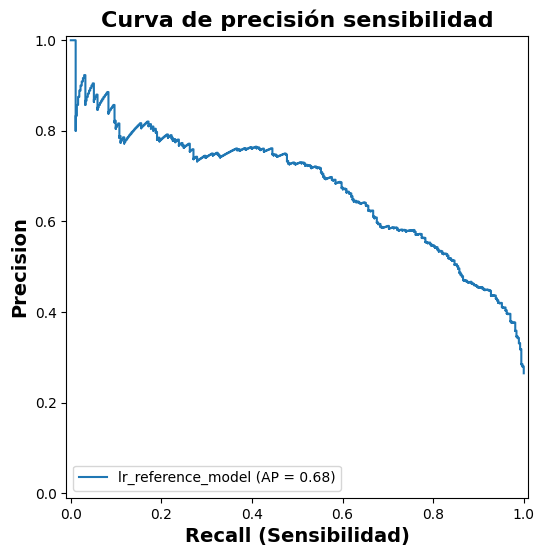

In [21]:
fig, ax = plt.subplots(figsize = (10,6))


PrecisionRecallDisplay.from_estimator(lr_reference_model, X_test, y_test, ax = ax, name='lr_reference_model')
ax.set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
ax.set_title('Curva de precisión sensibilidad', fontsize = 16, fontweight = 'bold')
plt.show()

#**Evaluar el overfitting del modelo**
* Para esto compararemos los resultados que nos dio al predecir el conjunto de test con respecto a los resultados que obtendremos del conjunto de train

In [22]:
y_pred_train = lr_reference_model.predict(X_train)

resultados_train_lr = classification_report(y_train, y_pred_train)
resultados_test_lr = classification_report(y_test, y_pred)

print(f'Resultados conjunto de entrenamiento:  \n\n {resultados_train_lr} \n\n resultados conjunto de test: \n\n {resultados_test_lr}')

Resultados conjunto de entrenamiento:  

               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.65      0.53      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.79      5634
 

 resultados conjunto de test: 

               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



##**Guardar métricas del base model**

In [23]:
guardar_metricas("LR Baseline", y_test, y_pred)

#**Segundo Modelo Regresión logística con Class_weight**
* Probaré un segundo modelo utilizando el parámetro weighted de regresión logística para que le dé más peso a la clase que aparece menos, para esto debo copiar el Pipeline hecho anteriormente y modificar un parámetro del modelo, se hizo una copia de este en vez de modificar el primer Pipeline para luego poder comparar con otros métodos de balanceo de clases como Smote o NearMiss

In [24]:
lr_balanceado = clone(pipeline_lr)
lr_balanceado.set_params(model = LogisticRegressionCV(class_weight='balanced'))
lr_balanceado.fit(X_train, y_train)
y_pred_lr_balanceado = lr_balanceado.predict(X_test)
y_pred_proba_lr_balanceado = lr_balanceado.predict_proba(X_test)

#**Métricas para evaluar el modelo**

In [25]:
print(classification_report(y_test, y_pred_lr_balanceado))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



#**Comparación de gráficos de Precisión Sensibilidad**

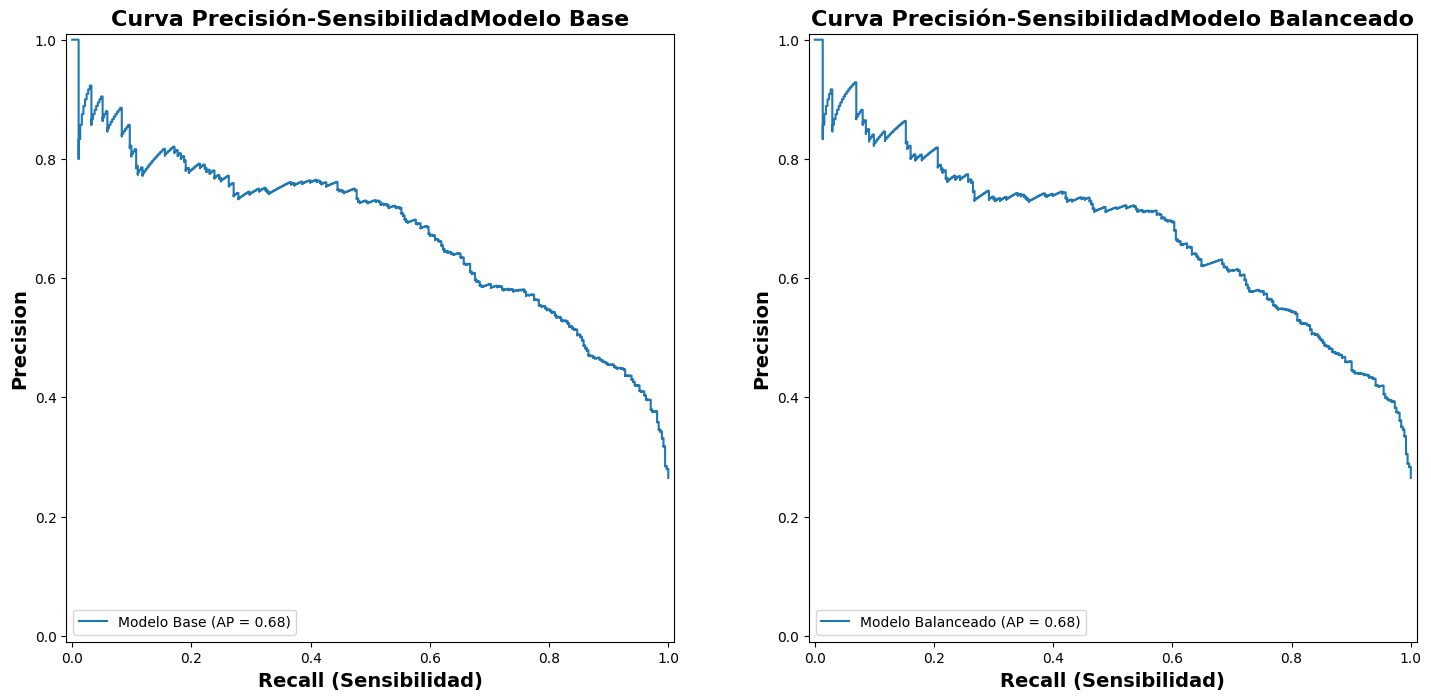

In [26]:
lista_modelos_lr_balanceado = [(lr_reference_model,'Modelo Base'), (lr_balanceado,'Modelo Balanceado')]

graficar_curvas_precision_recall(lista_modelos_lr_balanceado)


##**Guardar métricas del modelo con class weight**

In [27]:
guardar_metricas("LR Class Weight", y_test, y_pred_lr_balanceado)

#**Modelo utilizando Smote para balancear**
* Aquí crearé un nuevo Pipeline basándome en el original, pero antes de seleccionar el modelo, se agrega una técnica de balanceo llamada SMOTE

In [28]:
lr_smote = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegressionCV())])

lr_smote.fit(X_train, y_train)
y_pred_lr_smote = lr_smote.predict(X_test)
y_pred_proba_lr_smote = lr_smote.predict_proba(X_test)

#**Métricas del modelo Logistic Regression con SMOTE**

In [29]:
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.54      0.72      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



##**Comparar gráfico de precisión Sensibilidad para Modelo con balanceo SMOTE**

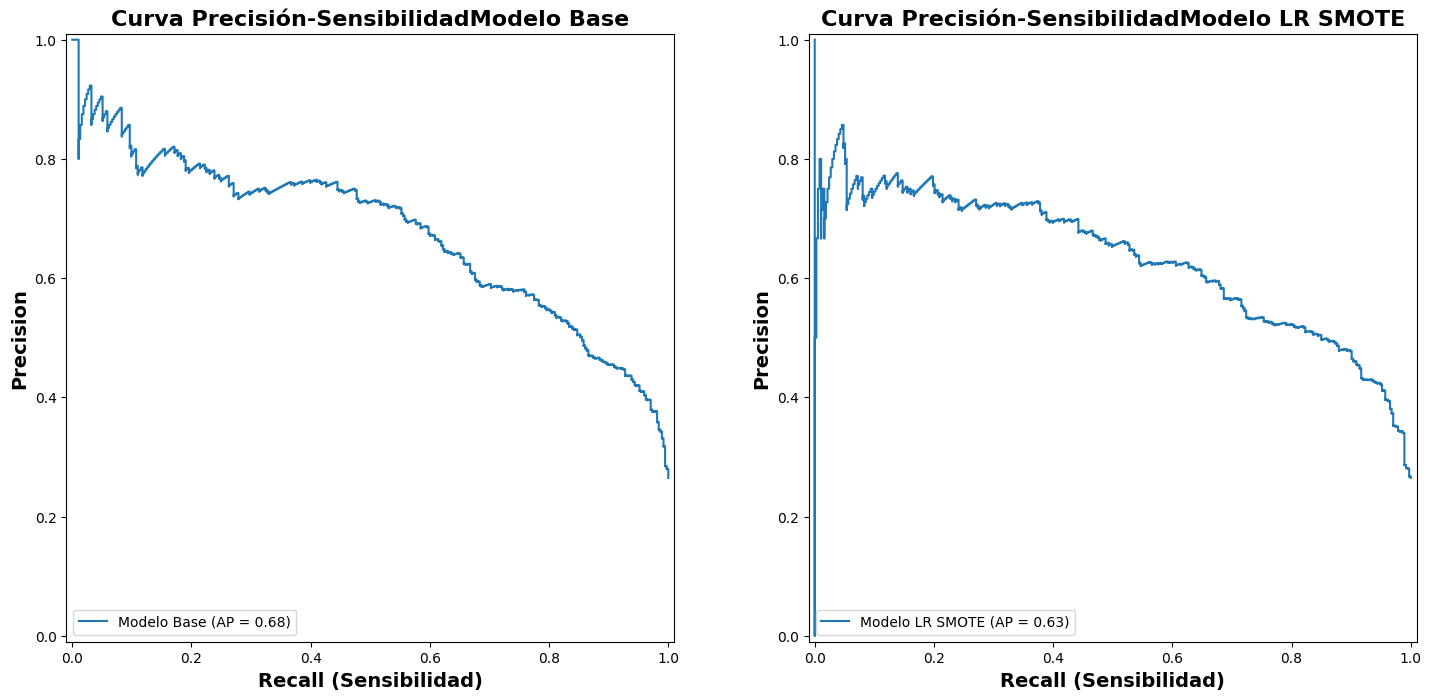

In [30]:
lista_modelos_lr_smote = [(lr_reference_model, 'Modelo Base'), (lr_smote, 'Modelo LR SMOTE')]

graficar_curvas_precision_recall(lista_modelos_lr_smote)

##**Guardar métricas regresión logística con SMOTE**

In [31]:
guardar_metricas("LR SMOTE", y_test, y_pred_lr_smote)

#**Modelo utilizando NearMiss para balancear**
* Ahora se utilizará otra técnica para balancear los datos, también se debe realizar otro Pipeline para procesar estos datos e incluir el balanceador.

In [32]:
lr_near_miss = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('near_miss', NearMiss(version=3)),
    ('model', LogisticRegressionCV())])

lr_near_miss.fit(X_train, y_train)
y_pred_lr_near_miss = lr_near_miss.predict(X_test)
y_pred_proba_lr_near_miss = lr_near_miss.predict_proba(X_test)

#**Métricas para NearMiss**

In [33]:
print(classification_report(y_test, y_pred_lr_near_miss))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1036
           1       0.59      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



##**Comparación de gráfico Precisión Sensibilidad para Modelo NearMiss**

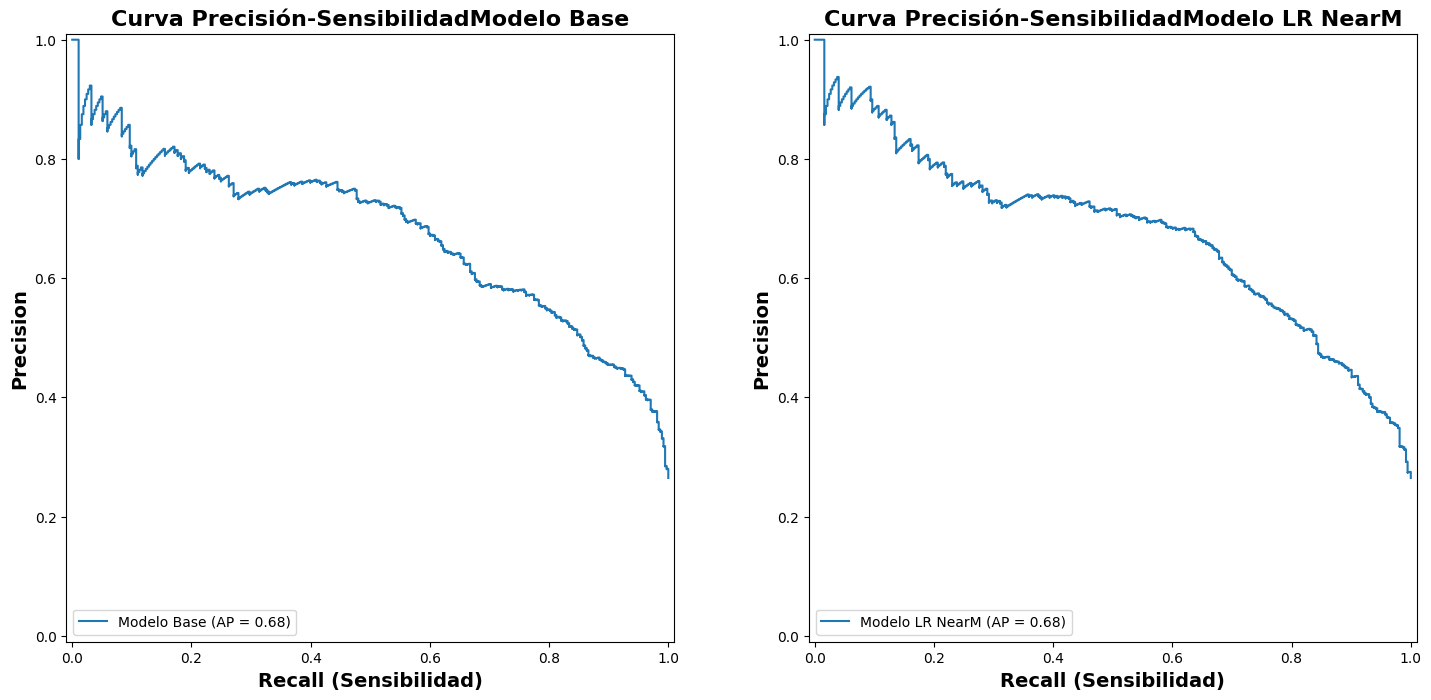

In [34]:
lista_modelos_lr_near_miss = [
    (lr_reference_model,'Modelo Base'), (lr_near_miss,'Modelo LR NearM')]

graficar_curvas_precision_recall(lista_modelos_lr_near_miss)

##**Guardar métricas modelo Logistic Regression NEARMISS**

In [35]:
guardar_metricas("LR NearMiss", y_test, y_pred_lr_near_miss)

#**Conclusión de modelos lineales**
* Hasta el momento el mejor modelo es la regresión lineal sin utilizar técnicas de balanceo de datos adicionales a las que aporta el mismo modelo.
* Aplicar distintas técnicas de balance no ha mejorado el modelo, probablemente se deba a que las clases no están tan desbalanceadas y el modelo es capaz de detectar la diferencia entre ellas.

#**Modelos Xgboost**
* Se utilizará un modelo diferente basado en árboles para poder comparar con el baseline

In [36]:
pipeline_no_lineal_ohe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OneHotEncoder(variables=lista_strings, drop_last=True, top_categories=None)),
    ('model', XGBClassifier())
  ])

pipeline_no_lineal_le = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OrdinalEncoder(encoding_method='ordered', variables=lista_strings)),
    ('model', XGBClassifier())
])

##**Definir una función con Optuna para optimizar hiperparámetros**
* Se define una función que permita optimizar hiperparámetros para obtener una idea inicial de qué tan bueno es el modelo

###**Pipeline para modelos no lineales**
* En este caso no es necesario utilizar un escalamiento de las variables ya que los modelos de árboles no son sensibles a la magnitud de las variables continuas, además probaré utilizando OneHotEncoder y OrdinalEncoder para ver cual da mejores resultados

##**Modelo Xgboost con OneHotEncoder**

In [37]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective_ohe(trial):
  params = {
      "max_depth": trial.suggest_int("max_depth", 2, 20),
      "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree",0.3,1.0)
  }

  pipeline = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OneHotEncoder(variables=lista_strings, drop_last=True, top_categories=None)),
    ('model', XGBClassifier(**params, scale_pos_weight = scale_pos_weight, eval_metric = "logloss", random_state=42))
  ])

  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  scorer = make_scorer(f1_score, pos_label=1)

  scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring=scorer)

  return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_ohe = optuna.create_study(direction='maximize')
study_ohe.optimize(objective_ohe, n_trials=30)
print(study_ohe.best_params)

{'max_depth': 2, 'n_estimators': 264, 'learning_rate': 0.060384466384509464, 'subsample': 0.8172076908687611, 'colsample_bytree': 0.3663028442212264}


##**Entrenar el modelo XGBoostClassifier usando One Hot Encoder**

In [38]:
xgb_optuna_ohe =  clone(pipeline_no_lineal_ohe)
xgb_optuna_ohe.set_params(model=XGBClassifier (random_state=42, eval_metric="logloss", **study_ohe.best_params, n_jobs=-1))
xgb_optuna_ohe.fit(X_train, y_train)
y_pred_xgb_ohe = xgb_optuna_ohe.predict(X_test)

##**Metricas para evaluar el modelo**

In [39]:
print(classification_report(y_test, y_pred_xgb_ohe))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##**Curva Precisión - Recall para Xgboost con One Hot Encoder**

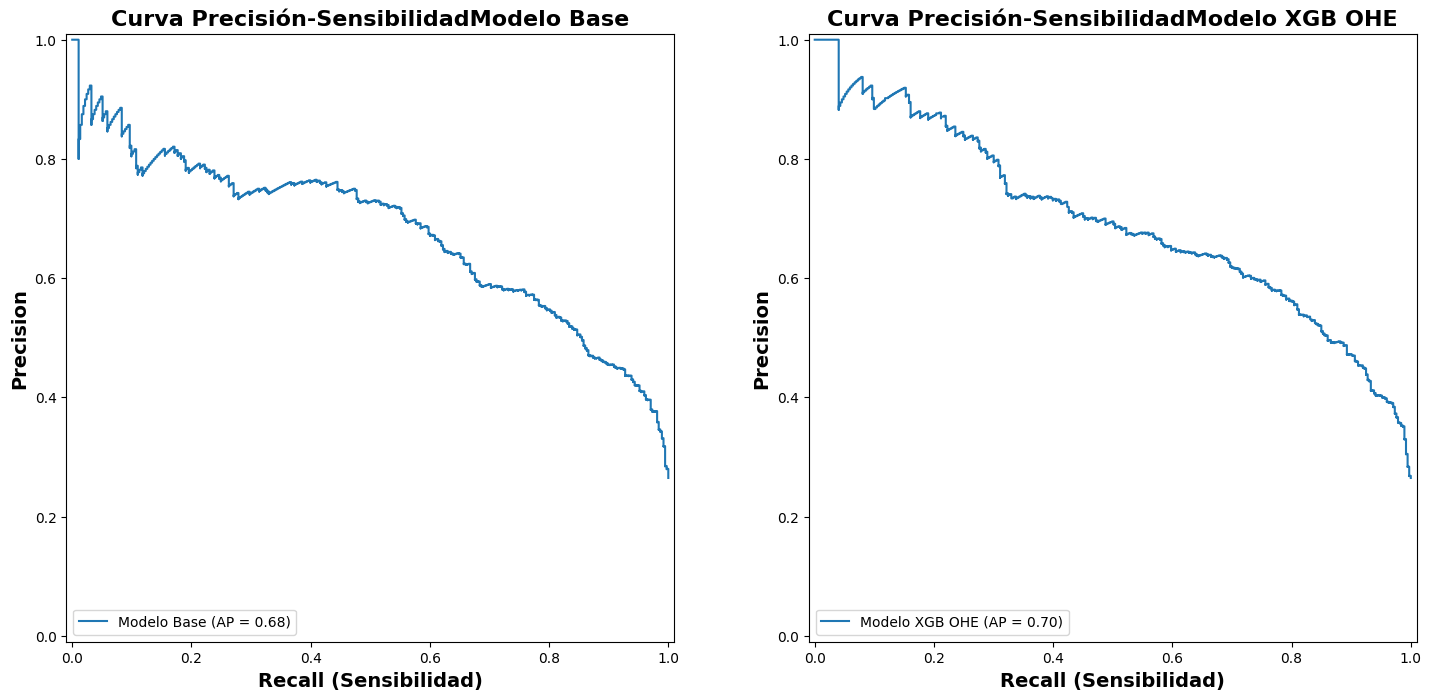

In [40]:
lista_modelos_xgb_ohe = [
    (lr_reference_model, "Modelo Base"), (xgb_optuna_ohe, "Modelo XGB OHE")]

graficar_curvas_precision_recall(lista_modelos_xgb_ohe)

##**Guardar métricas modelo XGBoost One Hot Encoder**

In [41]:
guardar_metricas('XGBoost OHE', y_test, y_pred_xgb_ohe)

##**Modelo Xgboot con Ordinal Encoder**

In [42]:
def objective_le(trial):
  params = {
      "max_depth": trial.suggest_int("max_depth", 3, 10),
      "n_estimators": trial.suggest_int("n_estimators",100, 2000),
      "learning_rate": trial.suggest_float("learning_rate",0.01, 0.3, log=True),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0)
  }

  pipeline = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OrdinalEncoder(variables=lista_strings, encoding_method="ordered")),
    ('model', XGBClassifier(**params, eval_metric = "logloss", random_state=42, scale_pos_weight= scale_pos_weight))
  ])

  cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)
  scorer = make_scorer(f1_score, pos_label=1)

  scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = scorer)
  return scores.mean()


study_le = optuna.create_study(direction="maximize")
study_le.optimize(objective_le, n_trials=30)
print(study_le.best_params)



{'max_depth': 3, 'n_estimators': 559, 'learning_rate': 0.01064768257512823, 'subsample': 0.8619498318652302, 'colsample_bytree': 0.8209966989578696}


##**Entrenar el modelo usando Ordinal Encoder**

In [43]:
xgb_optuna_le = clone(pipeline_no_lineal_le)
xgb_optuna_le.set_params(model = XGBClassifier(random_state=42, n_jobs=-1, **study_le.best_params, eval_metric="logloss"))
xgb_optuna_le.fit(X_train, y_train)
y_pred_xgb_le = xgb_optuna_le.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred_xgb_le))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##**Gráfico Precision Recall XGBoost Ordinal Encoder**

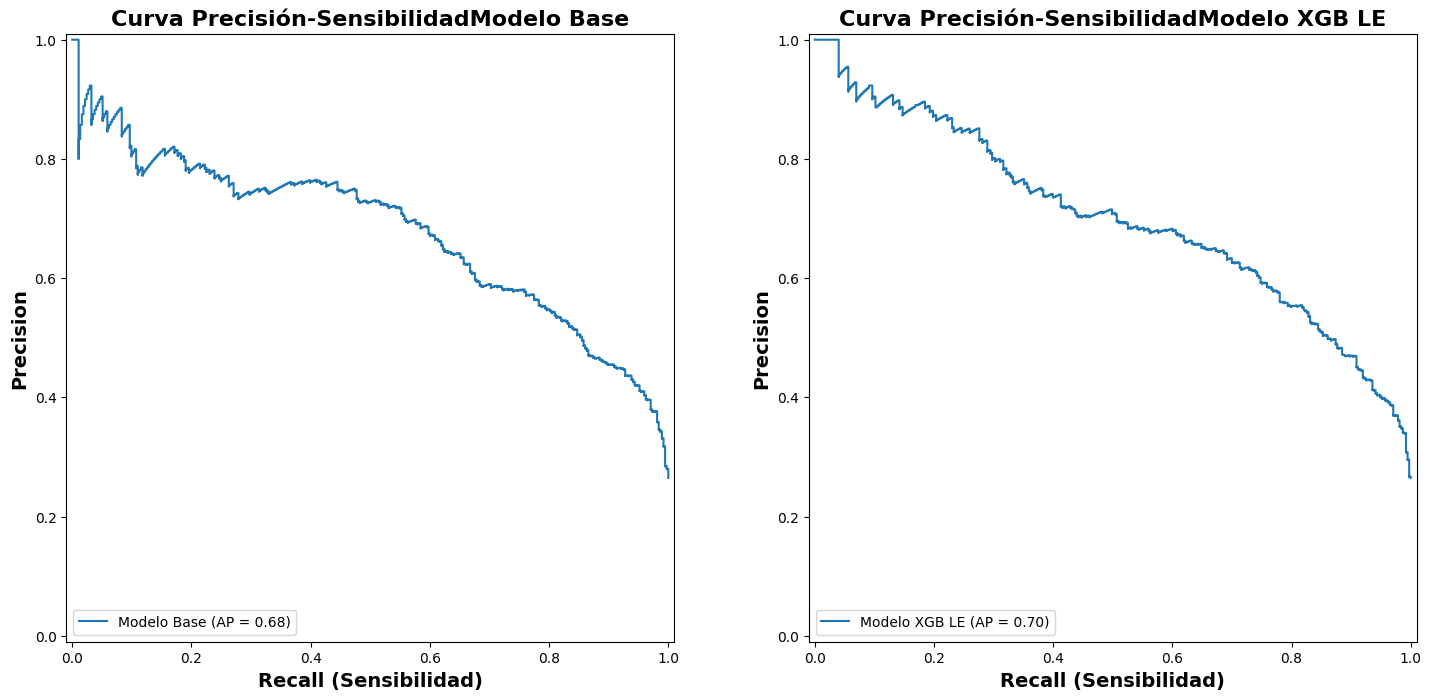

In [45]:
lista_modelos_xgb_le = [
    (lr_reference_model, 'Modelo Base'), (xgb_optuna_le, 'Modelo XGB LE')]

graficar_curvas_precision_recall(lista_modelos_xgb_le)

##**Guardar métricas modelo XGBOOST Ordinal Encoder**

In [46]:
guardar_metricas('XGBoost LE', y_test, y_pred_xgb_le)

#**Evaluar la importancia de las características para el Baseline Modelo utilizando sus coeficientes**

/tmp/ipykernel_570/3994403163.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coeficientes_lr.values,


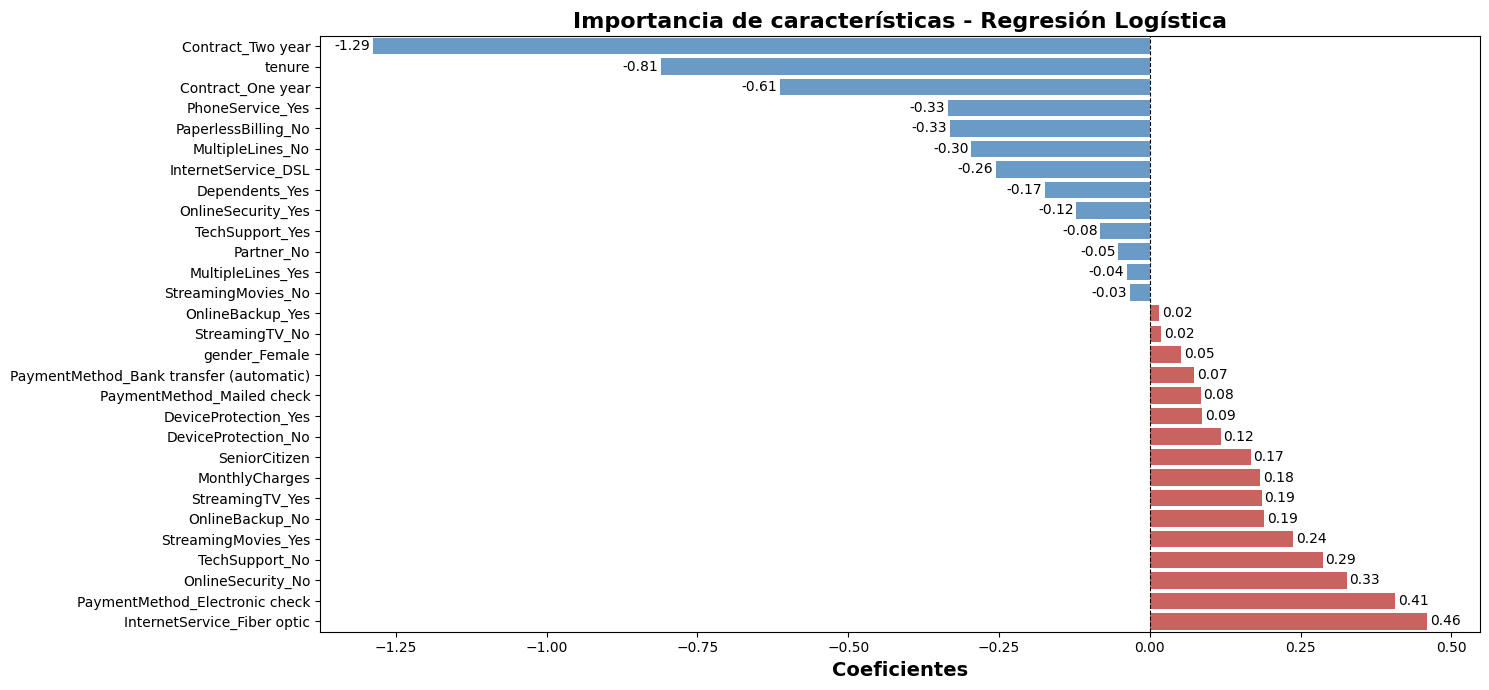

In [47]:
model_lr = lr_reference_model.named_steps['model']
encoder = lr_reference_model.named_steps['encoding']
model_columns = encoder.get_feature_names_out()

coeficientes_lr = pd.Series(model_lr.coef_[0], index= model_columns).sort_values()

fix, ax = plt.subplots(figsize = (15,7))
ax = sns.barplot(x=coeficientes_lr.values,
                 y = coeficientes_lr.index,
                 palette=['#d9534f' if v > 0 else '#5b9bd5' for v in coeficientes_lr.values],
                 ax=ax)
ax.axvline(x=0, color="black", linestyle='--', linewidth=0.8)
ax.set_title('Importancia de características - Regresión Logística', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.2f}',padding=2)
ax.set_ylabel('')
ax.set_xlabel('Coeficientes', fontsize=14, fontweight= 'bold')
plt.tight_layout()
plt.show()


#**Evaluar la importancia de características para el Baseline Model usando Shap**

##**Gráfico de barras de importancia global de las variables**


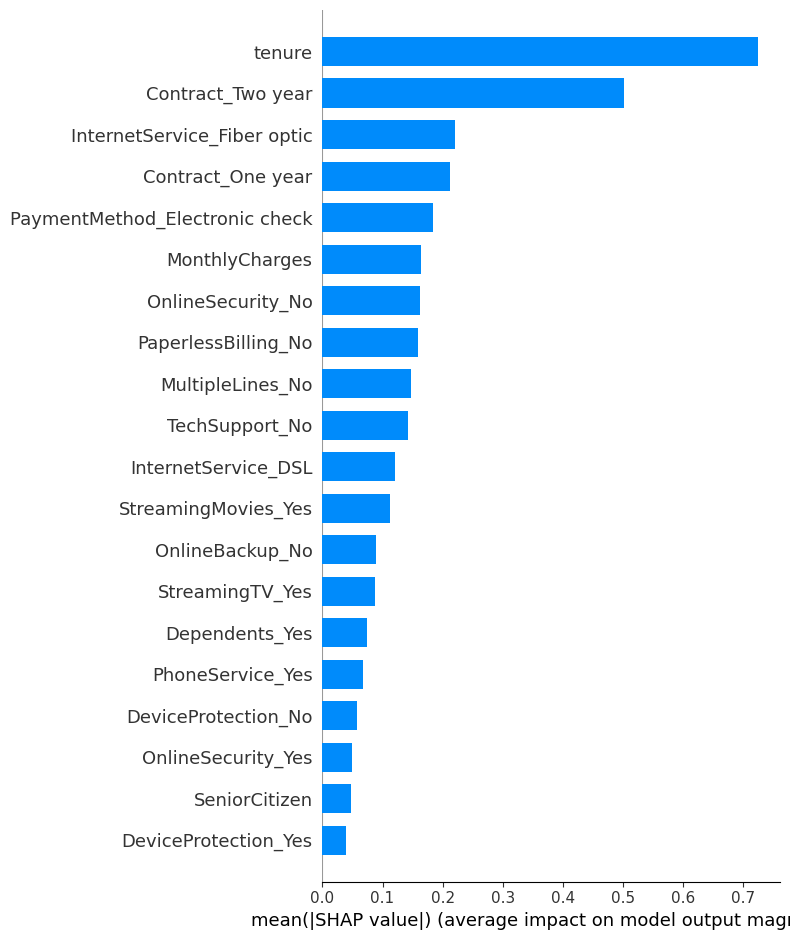

In [48]:
preprocesor = Pipeline(lr_reference_model.steps[:-1])
X_train_transform_reference_model = preprocesor.transform(X_train)

explainer = shap.LinearExplainer(lr_reference_model.named_steps['model'],
                                 X_train_transform_reference_model)

shap_values_lr_base_model = explainer.shap_values(X_train_transform_reference_model)

shap.summary_plot(shap_values_lr_base_model, X_train_transform_reference_model, plot_type='bar', max_display=20  )

##**Beeswarm Plot Baseline Model**

* Muestra todas las predicciones, se puede ver una distribución y dirección
* Al parecer la variable más importante es tenure, a valores bajos de la variable aumenta la probabilidad de que un cliente se vaya, mientras que a valores altos de la variable disminuye la probabilidad que un cliente se vaya.

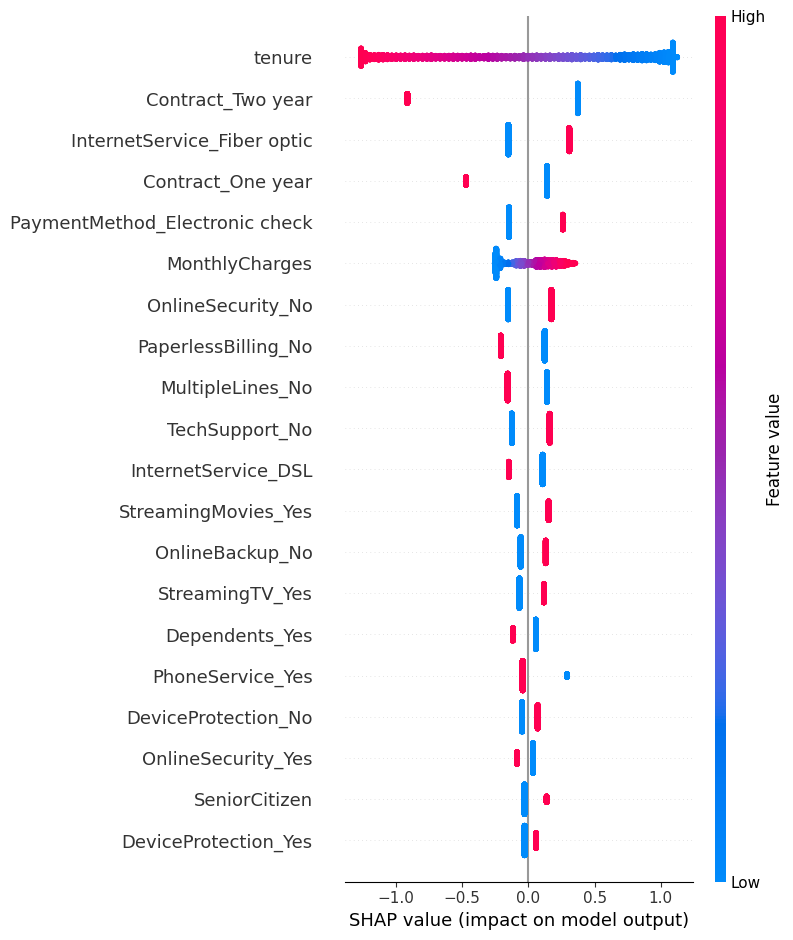

In [49]:
shap.summary_plot(shap_values_lr_base_model, X_train_transform_reference_model, plot_type='dot')

#**Evaluar la importancia de las características para el modelo NearMiss**

/tmp/ipykernel_570/1721205704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coeficientes_lr_near_miss.values,


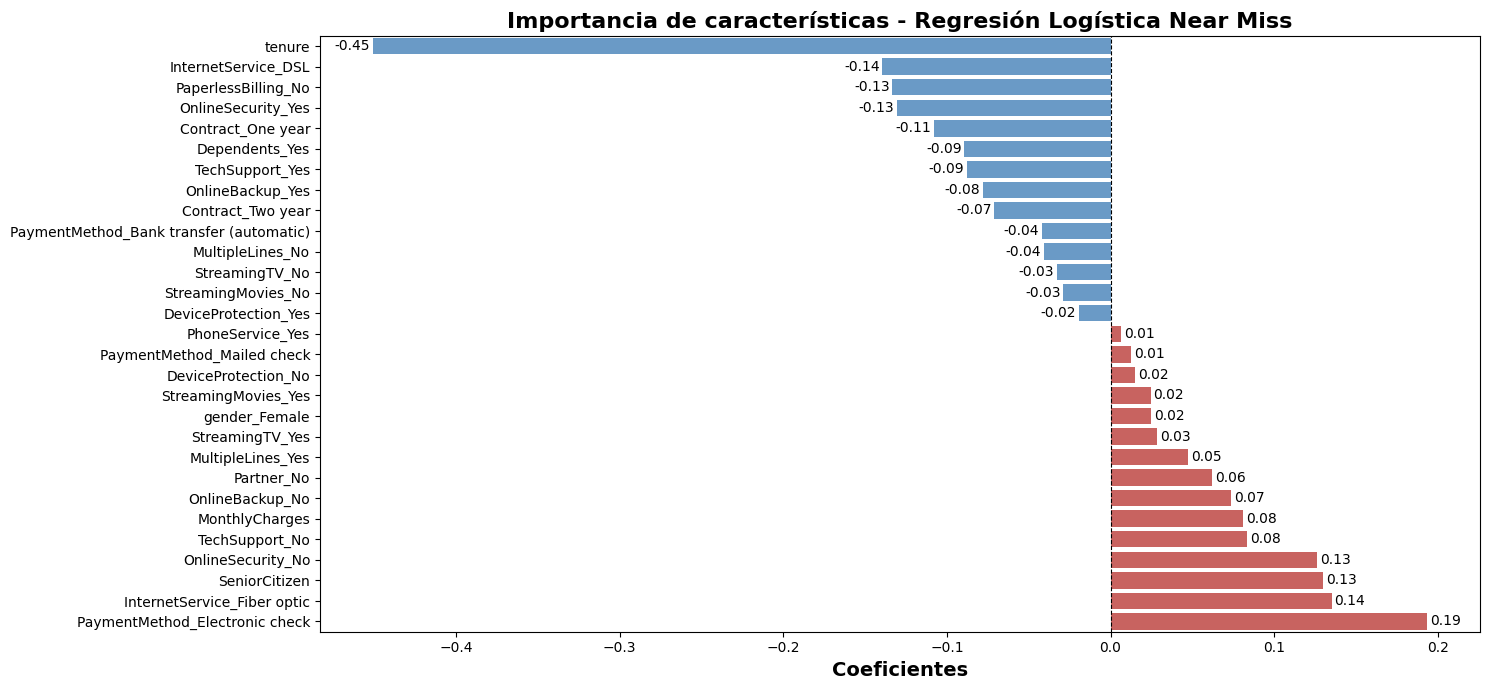

In [50]:
model_lr_near_miss = lr_near_miss.named_steps['model']
encoder_near_miss = lr_near_miss.named_steps['encoding']
model_columns_near_miss = encoder_near_miss.get_feature_names_out()

coeficientes_lr_near_miss = pd.Series(model_lr_near_miss.coef_[0], index= model_columns_near_miss).sort_values()

fix, ax = plt.subplots(figsize = (15,7))
ax = sns.barplot(x=coeficientes_lr_near_miss.values,
                 y = coeficientes_lr_near_miss.index,
                 palette=['#d9534f' if v > 0 else '#5b9bd5' for v in coeficientes_lr_near_miss.values],
                 ax=ax)
ax.axvline(x=0, color="black", linestyle='--', linewidth=0.8)
ax.set_title('Importancia de características - Regresión Logística Near Miss', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.2f}',padding=2)
ax.set_ylabel('')
ax.set_xlabel('Coeficientes', fontsize=14, fontweight= 'bold')
plt.tight_layout()
plt.show()


##**Evaluar la importancia de las características para Logistic Regression Near Miss con Shap**

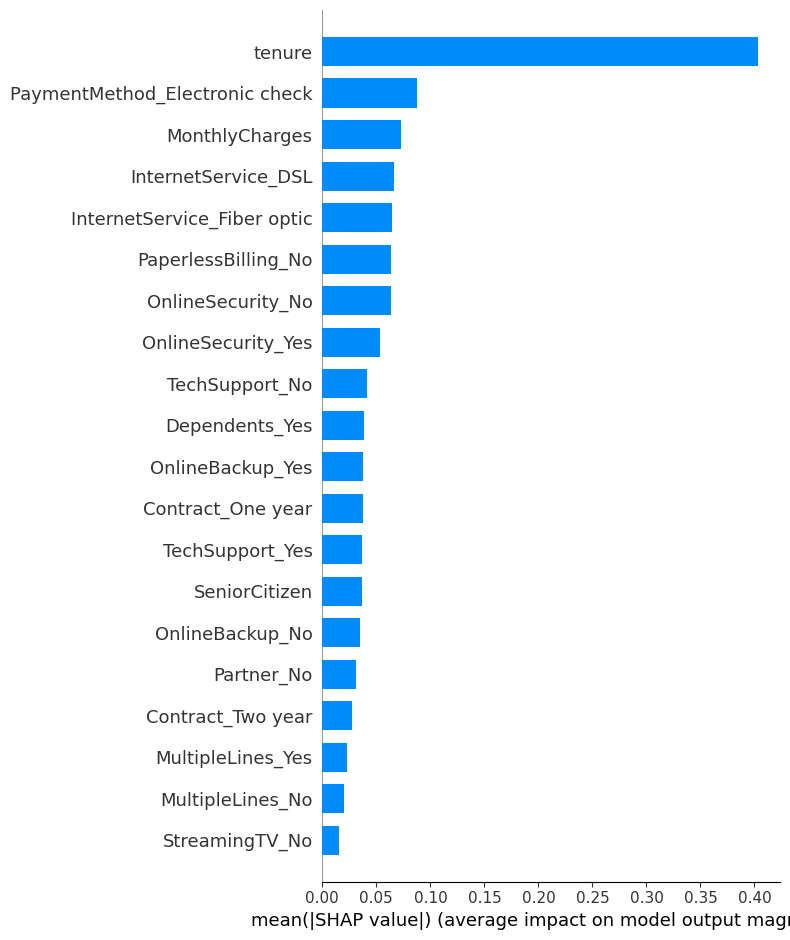

In [51]:
preprocesor_lr_near_miss = Pipeline([
    ('Selector', lr_near_miss.named_steps['Selector']),
    ('scaler', lr_near_miss.named_steps['scaler']),
    ('encoding', lr_near_miss.named_steps['encoding'])
])
X_train_transform_lr_near_miss = preprocesor_lr_near_miss.transform(X_train)

explainer_lr_near_miss  = shap.LinearExplainer(lr_near_miss.named_steps['model'],
                                               X_train_transform_lr_near_miss)

shap_values_lr_near_miss = explainer_lr_near_miss.shap_values(X_train_transform_lr_near_miss)
shap.summary_plot(shap_values_lr_near_miss, X_train_transform_lr_near_miss, plot_type='bar', max_display=20)

##**Beeswarm Plot Regresión logística con NearMiss**

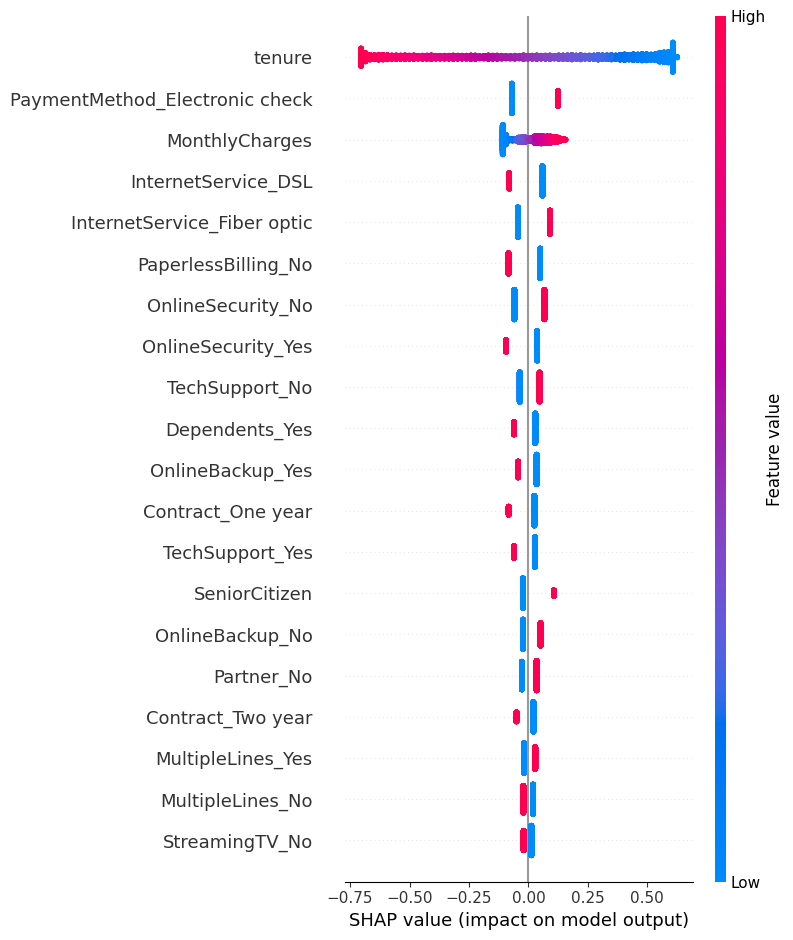

In [52]:
shap.summary_plot(shap_values_lr_near_miss, X_train_transform_lr_near_miss, plot_type='dot')

#**Evaluar la importancia de las características para XGBoost con One Hot Encoder con Shap**
##**Gráfico de barras**  

 99%|===================| 5560/5634 [00:17<00:00]       

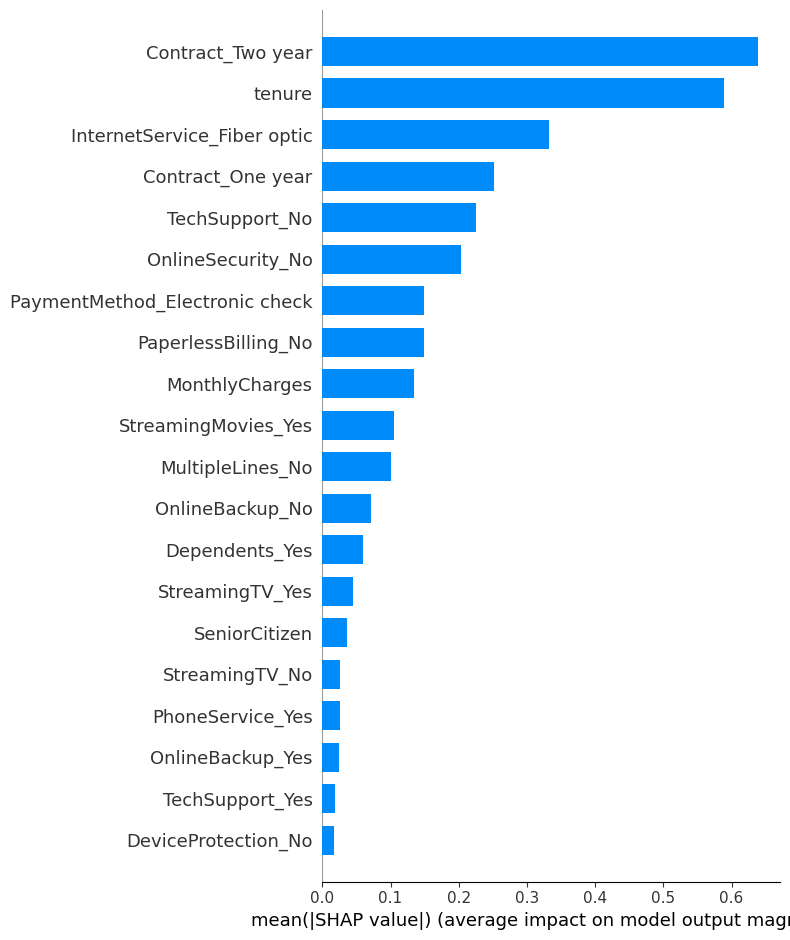

In [53]:
preprocesor_xgb_ohe = Pipeline(xgb_optuna_ohe.steps[:-1])
X_train_transform_xgb_ohe = preprocesor_xgb_ohe.transform(X_train)

explainer_xgb_ohe = shap.TreeExplainer(xgb_optuna_ohe.named_steps['model'],
                                       X_train_transform_xgb_ohe)

shap_values_xgb_ohe = explainer_xgb_ohe.shap_values(X_train_transform_xgb_ohe)
shap.summary_plot(shap_values_xgb_ohe, X_train_transform_xgb_ohe, plot_type='bar', max_display=20)

##**Beeswarm Plot XGBoost con One Hot Encoder**

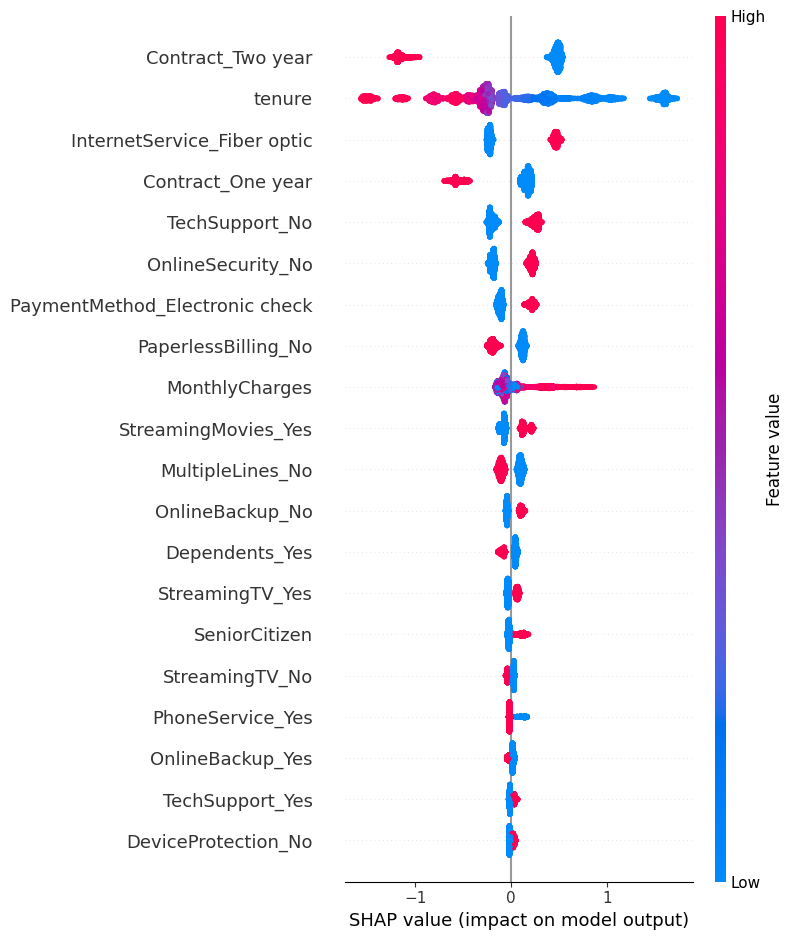

In [54]:
shap.summary_plot(shap_values_xgb_ohe, X_train_transform_xgb_ohe, plot_type='dot')

#**Evaluar la importancia de las características para XGBoost con Ordinal Encoder**
##**Gráfico de baras**

100%|===================| 5613/5634 [01:05<00:00]       

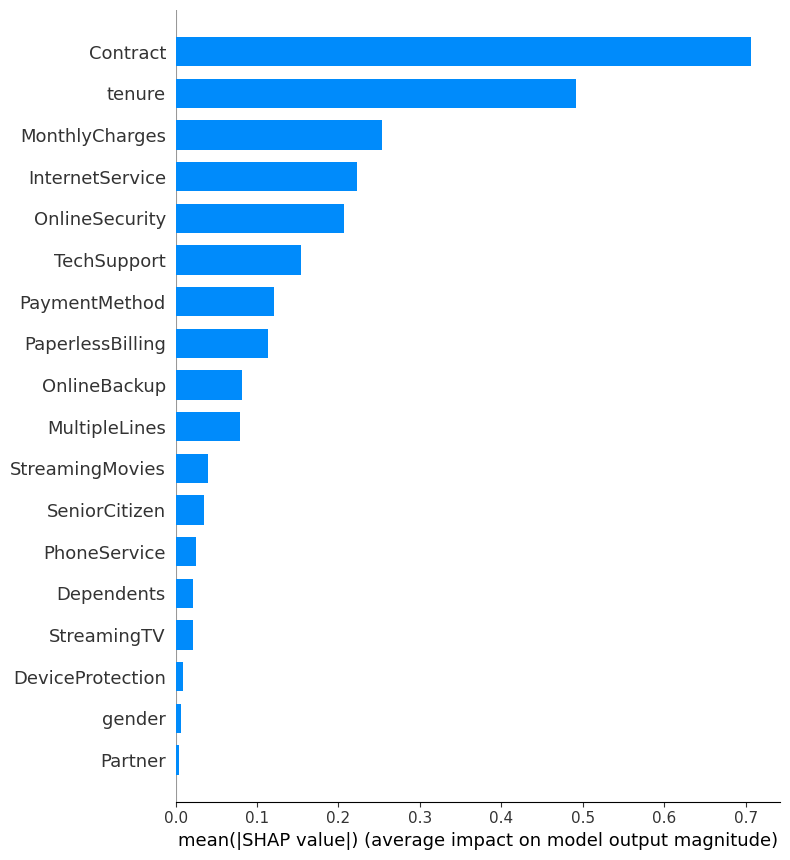

In [55]:
preprocesor_xgb_le = Pipeline(xgb_optuna_le.steps[:-1])
X_train_transform_xgb_le = preprocesor_xgb_le.transform(X_train)
explainer_xgb_le = shap.TreeExplainer(xgb_optuna_le.named_steps['model'],
                                      X_train_transform_xgb_le)

shap_values_xgb_le = explainer_xgb_le.shap_values(X_train_transform_xgb_le)
shap.summary_plot(shap_values_xgb_le, X_train_transform_xgb_le, plot_type='bar', max_display=20)

##**Beeswarm Plot XGBoost con Ordinal Encoder**

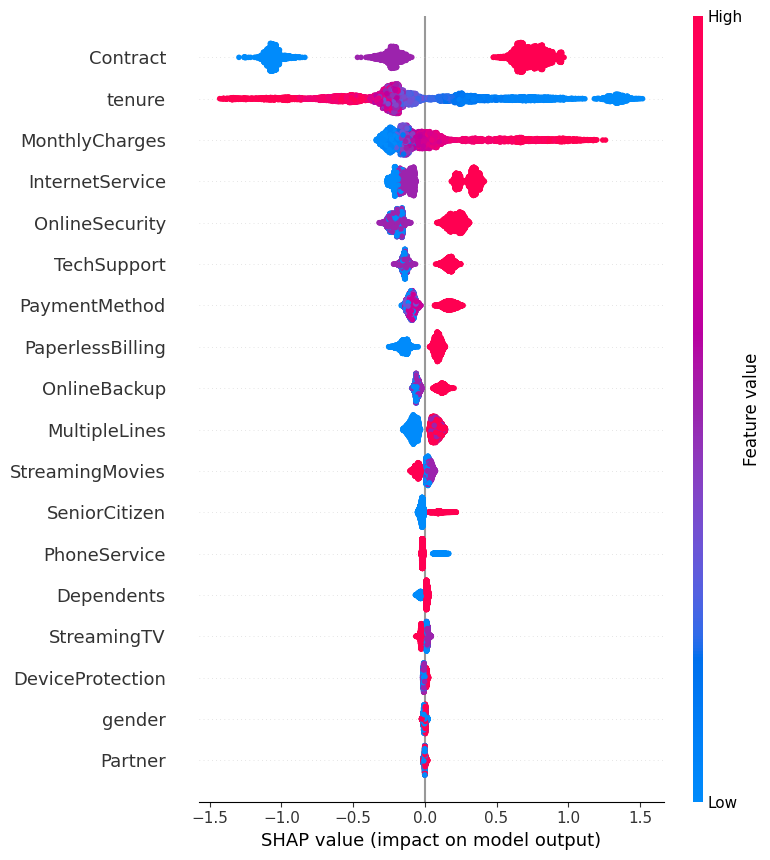

In [56]:
shap.summary_plot(shap_values_xgb_le, X_train_transform_xgb_le, plot_type='dot')

#**Visualizar los resultados de métricas de cada modelo**

In [57]:
df_metricas = pd.DataFrame(resultados_modelos).sort_values('F1 Churn', ascending=False)
df_metricas

,Modelo,F1 Churn,Precision Churn,Recall Churn,F1 Macro
3,LR NearMiss,0.647,0.587,0.721,0.750
1,LR Class Weight,0.642,0.530,0.815,0.730
0,LR Baseline,0.632,0.691,0.582,0.757
2,LR SMOTE,0.619,0.540,0.724,0.724
4,XGBoost OHE,0.597,0.673,0.536,0.736
5,XGBoost LE,0.596,0.688,0.525,0.736


#**Guardar métricas de modelos**

##**Guardar métricas del mejor modelo**

In [67]:
y_pred = lr_near_miss.predict(X_test)
y_proba = lr_near_miss.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict =True)

metricas = {
    "f1-score": round(report['1']['f1-score'], 3),
    "precision": round(report['1']['precision'], 3),
    "recall": round(report['1']['recall'], 3),
    "accuracy": round(report['accuracy'], 3),

    "confusion_matrix": cm.tolist(),

    "precision_curve":precision.tolist(),
    "recall_curve":recall.tolist(),
    "threshold":thresholds.tolist()
}

with open('metrics_best_model.json', mode='w') as file:
  json.dump(metricas, file)



In [58]:
df_metricas.to_csv("resultados_modelos.csv", index=False)

#**Guardar el pipeline y modelo**

In [59]:
sio.dump(lr_near_miss, "pipeline_near_miss.skops")

#**Conclusiones**

* Los mejores modelos que se obtuvieron son de Regresión Logística, en este caso resultados similares a modelos más potentes como XGBoost, probablemente se deba a que este problema podía resolverse como un problema de clasificación lineal, por lo que un modelo basado en árboles no aportaba mucha mejora al ser un modelo no lineal.
* Para este problema se hace el supuesto que es más costoso que se vaya un cliente sin haberlo detectado que contactar un cliente que no se iba a ir, haciendo una comparación entre los distintos modelos, varios obtuvieron un puntaje similar en f1-score, por lo tanto se da prioridad a la métrica de Recall, donde el mejor modelo es el que usa balanceo con NearMiss.
* En la curva de Precisión sensibilidad los modelos que presentaron un mejor desempeño fueron los de XGBoost, pero es muy leve la mejor y tuvo un tiempo de entrenamiento más alto debido al ajuste de hiperparámetros y la validación cruzada.
* Al parecer la variable más importante o que más afecta es tenure y también las variables que nos dicen si tiene contrato por uno o dos años.
* Otra variable importante es MonthlyCharges, a mayores valores la tendencia es que los clientes abandonen, tal vez no son tan convenientes los precios.
* Las variables que al parecer aportan menos información al modelo son el género, si tienen servicios de Streaming, ya sean de Tv o películas, el servicio de backup online, si la persona tiene contratada múltiples líneas y si vive o no solo.